In [44]:
import torch 
from cosmoford import NOISE_STD, THETA_MEAN, THETA_STD
from cosmoford.dataset import reshape_field_numpy
from cosmoford.models_nopatch import RegressionModelNoPatch, build_flow
from datasets import load_from_disk
import numpy as np

## Checking compressor

In [2]:
summaries_dir = "/home/noedia/links/projects/rrg-lplevass/noedia/wl_neurips/ciela_branch/CosmOrford/"
budget_list = [100, 500, 1000, 5000, 10000, 20200]

budget = budget_list[0]
data_dir = summaries_dir + f"budget-{budget}/summaries_n16.pt" 
data = torch.load(data_dir, weights_only=False, map_location="cpu")

1) Load a compressor
2) Forward pass a few samples from the dataset to get mean and std
3) Plot true vs predicted 

In [50]:
compressor_dir = "/home/noedia/links/scratch/wl_chall/budget_scan_nbody_final/budget-20200/checkpoints/step=11500-val_log_prob=0.2271.ckpt"
device = "cpu"
holdout_dir = "/home/noedia/links/projects/rrg-lplevass/shared/wl_chall_data/neurips-wl-challenge-holdout"

# ── 1. Load frozen compressor ──
ckpt_path = compressor_dir
compressor = RegressionModelNoPatch.load_from_checkpoint(ckpt_path, map_location=device)
compressor.eval()
compressor.to(device)
for p in compressor.parameters():
    p.requires_grad = False
print(f"Loaded compressor from {ckpt_path}")

# ── 2. Load holdout dataset ──
print("Loading holdout dataset...")
holdout = load_from_disk(holdout_dir)
holdout = holdout["train"]
holdout = holdout.with_format("numpy")

kappa_all = np.array(holdout["kappa"])  # (N, 1424, 176)
theta_all = np.array(holdout["theta"])  # (N, 5)

num_points = 50
kappa_all = kappa_all[:num_points]
theta_all = theta_all[:num_points]

Loaded compressor from /home/noedia/links/scratch/wl_chall/budget_scan_nbody_final/budget-20200/checkpoints/step=11500-val_log_prob=0.2271.ckpt
Loading holdout dataset...


Predicting mean and std for a few held out samples. 

In [62]:
# Normalize theta to match training (only Omega_m, S_8)
theta_norm = (theta_all[:, :2] - THETA_MEAN[:2]) / THETA_STD[:2]
theta_norm = theta_norm.astype(np.float32)

n_maps = len(kappa_all)
print(f"Holdout: {n_maps} maps")

# Build mask (same as model uses)
from cosmoford import SURVEY_MASK
mask = np.concatenate([SURVEY_MASK[:, :88], SURVEY_MASK[620:1030, 88:]])

# ── 3. Pre-compute summaries with noise augmentation ──
all_means = []
all_stds = []
all_thetas = []

with torch.no_grad():
    for i in range(n_maps):
        kappa_i = kappa_all[i]  # (1424, 176)
        kappa_reshaped = reshape_field_numpy(kappa_i[np.newaxis])[0]  # (1834, 88)

        noise = np.random.randn(*kappa_reshaped.shape).astype(np.float32) * NOISE_STD
        noisy = (kappa_reshaped + noise) * mask
        x = torch.from_numpy(noisy).unsqueeze(0).to(device)  # (1, 1834, 88)
        mean, std, s = compressor(x)  # (1, 8)
        all_means.append(mean.cpu())
        all_stds.append(std.cpu())
        all_thetas.append(theta_norm[i])

        if (i + 1) % 1000 == 0:
            print(f"  Processed {i+1}/{n_maps} maps")

all_means = np.array(all_means) * THETA_STD[:2] + THETA_MEAN[:2]
all_stds = np.array(all_stds) * THETA_STD[:2]
all_thetas = np.array(all_thetas)* THETA_STD[:2] + THETA_MEAN[:2]

Holdout: 50 maps


Plotting predicted vs true

In [59]:


print(all_means.shape)
print(all_thetas.shape)

(50, 1, 2)
(50, 2)


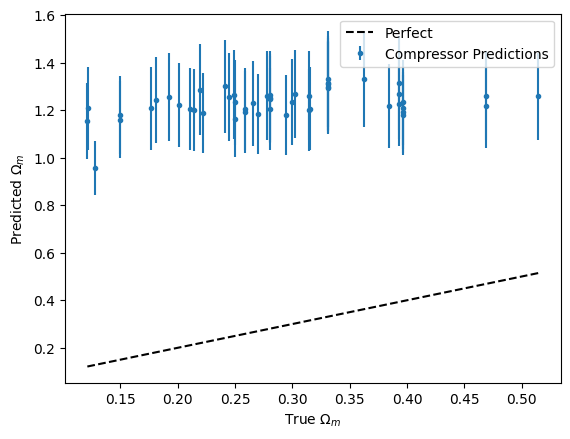

In [68]:
import matplotlib.pyplot as plt
omegam_mean = all_means[:, 0, 0]
omegam_std = all_stds[:, 0, 0] 
omegam_true = all_thetas[:, 0]


plt.errorbar(omegam_true, omegam_mean, fmt = ".", yerr = omegam_std, label = "Compressor Predictions")
plt.plot([omegam_true.min(), omegam_true.max()],[omegam_true.min(), omegam_true.max()], color = "k", ls = "dashed", label = "Perfect")
plt.xlabel(r"True $\Omega_m$")
plt.ylabel(r"Predicted $\Omega_m$")
plt.legend()

In [65]:
theta_all

array([[-0.75762504, -0.28749958],
       [-1.6020833 , -0.13020724],
       [-0.9560716 , -0.19666795],
       [-1.1050946 , -0.32402462],
       [-1.3882964 , -0.0610508 ],
       [-1.2703892 , -0.2479246 ],
       [-1.1050946 , -0.32402462],
       [-0.6647541 , -0.26261017],
       [-0.9342889 , -0.23804286],
       [-1.2228159 , -0.16584145],
       [-1.3904594 , -0.17720723],
       [-1.9024675 , -0.07025296],
       [-1.65026   , -0.30968234],
       [-1.1050946 , -0.32402462],
       [-1.3874952 , -0.22255342],
       [-1.2703892 , -0.2479246 ],
       [-1.2703892 , -0.2479246 ],
       [-1.2815741 , -0.2621942 ],
       [-1.3272711 , -0.20609699],
       [-1.5413121 , -0.14935733],
       [-1.5032778 , -0.08218077],
       [-1.1050946 , -0.32402462],
       [-1.1979907 , -0.1899871 ],
       [-0.9258303 , -0.14598651],
       [-1.1562897 , -0.18487065],
       [-0.9258303 , -0.14598651],
       [-2.059639  , -0.047549  ],
       [-2.1111386 , -0.12672819],
       [-1.3513135 ,